# Прямое сравнение со статьёй

Чтобы результаты можно было сопоставлять со статьёй **напрямую**, здесь
воспроизведён её протокол оценки один-в-один (раздел 5.1 статьи):

* **регрессия** (`XUVInt`, `Helium`, `Msw`): MAPE и R², причём для мультиголовых
  моделей — **«for the best of the five heads»** (метрика по лучшей из 5 голов);
* **классификация** (`H2a`): accuracy, precision, recall, ROC-AUC;
* **все метрики — с 95% доверительными интервалами через bootstrap
  валидационной выборки** (1000 ресэмплов), ровно как в статье.

Опорные числа статьи (её таблица 2 / раздел 5.3):

| Параметр | Статья, MAPE / AUC |
|---|---|
| F_XUV | 20.4% [15.2; 27.2] |
| He/H | 17.9% [15.4; 20.6] |
| logMsw | 1.8% [1.4; 2.1] |
| H2a | ROC-AUC 0.989 |

Мы приводим **две** наши модели под этим же протоколом:
1. **Paper-matched** — одна мультиголовая CNN, 5 голов, метрика по лучшей из 5
   голов (это в точности конфигурация «multi-head model» статьи);
2. **Full pipeline** — наш ансамбль (5 сетей) + ранкер + отбор 5 кандидатов
   (`dl_pro`), метрика по лучшему из 5 отобранных кандидатов.

> Важная оговорка: у статьи своя валидационная выборка и своё разбиение;
> мы используем случайный hold-out 20% (seed 42, стратификация по H2a).
> Совпадают **определения метрик и протокол**, но не конкретные примеры в
> валидации — поэтому это сравнение методологически корректное, но не
> «на одних и тех же данных».

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score,
                             recall_score, r2_score)
from scipy.spatial.distance import cdist

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available() else "cpu")
print("device:", DEVICE)

device: mps


## 1. Данные (сплит как в основном решении)

In [2]:
DATA_DIR = "new_dataset_V3"
GRID = np.arange(-5.0, 5.0 + 1e-9, 0.1)
profiles, targets = [], []
for name in sorted(os.listdir(DATA_DIR)):
    path = os.path.join(DATA_DIR, name)
    if not os.path.isdir(path):
        continue
    params = {}
    with open(os.path.join(path, "parameters.txt")) as f:
        for line in f:
            p = line.split()
            if len(p) >= 2:
                params[p[0]] = p[1]
    arr = np.loadtxt(os.path.join(path, "Absorption.dat"), skiprows=1)
    if arr[-1, 0] - arr[0, 0] < 5:
        continue
    profiles.append(np.interp(GRID, arr[:, 0], arr[:, 1], left=0, right=0))
    targets.append([float(params["XUVInt"]), float(params["Helium"]),
                    float(params["Msw"]), int(params["H2a"])])
profiles = np.array(profiles, dtype=np.float32)
targets = np.array(targets)
y_reg = np.log10(targets[:, :3])
y_cls = targets[:, 3].astype(np.float32)
idx_train, idx_val = train_test_split(np.arange(len(profiles)), test_size=0.2,
                                      random_state=SEED, stratify=y_cls)
y_mean, y_std = y_reg[idx_train].mean(0), y_reg[idx_train].std(0)
x_scale = profiles[idx_train].max()
true_log = y_reg[idx_val]
true_lin = 10 ** true_log
cls_val = y_cls[idx_val]

log_prof = np.log10(np.clip(profiles, 1e-7, None))
mu = log_prof[idx_train].mean(0)
_, _, Vt = np.linalg.svd(log_prof[idx_train] - mu, full_matrices=False)
Z = (log_prof - mu) @ Vt[:16].T
Z = ((Z - Z[idx_train].mean(0)) / Z[idx_train].std(0)).astype(np.float32)
print("train:", len(idx_train), " val:", len(idx_val))

train: 490  val: 123


## 2. Определения метрик — точно по статье

`best-of-5` означает: для каждого профиля из 5 кандидатов берётся ближайший к
истине, и уже по нему считается ошибка (для регрессии — по каждому параметру
отдельно, как в статье «best of the five heads»). MAPE — в линейной шкале для
`XUVInt`/`Helium`, по `log10` для `Msw` (у статьи logMsw). R² — в лог-шкале
(естественно для величин, меняющихся на порядки). Доверительные интервалы —
bootstrap по валидации, 1000 ресэмплов.

In [3]:
def best_head(cands_log, j, log_scale):
    """Индекс ближайшего к истине кандидата по параметру j (в нужной шкале)."""
    if log_scale:
        d = np.abs(cands_log[:, :, j] - true_log[:, j:j+1])
    else:
        d = np.abs(10**cands_log[:, :, j] - true_lin[:, j:j+1])
    return d.argmin(1)


def reg_metrics(cands_log, j, log_scale, n_boot=1000):
    """MAPE и R² (best-of-5) с 95% bootstrap CI."""
    bh = best_head(cands_log, j, log_scale)
    pred_log = np.take_along_axis(cands_log[:, :, j], bh[:, None], 1)[:, 0]
    if log_scale:
        t, p = true_log[:, j], pred_log
        ape = np.abs(p - t) / np.abs(t)
    else:
        t, p = true_lin[:, j], 10**pred_log
        ape = np.abs(p - t) / t
    # точечные оценки
    mape = 100 * ape.mean()
    r2 = r2_score(true_log[:, j], pred_log)      # R² всегда в лог-шкале
    # bootstrap
    n = len(t)
    mb, rb = [], []
    for _ in range(n_boot):
        ix = np.random.randint(0, n, n)
        mb.append(100 * ape[ix].mean())
        rb.append(r2_score(true_log[ix, j], pred_log[ix]))
    return (mape, np.percentile(mb, 2.5), np.percentile(mb, 97.5),
            r2, np.percentile(rb, 2.5), np.percentile(rb, 97.5))


def cls_metrics(proba, n_boot=1000):
    y = cls_val
    pred = (proba > 0.5).astype(int)
    pt = dict(acc=accuracy_score(y, pred),
              prec=precision_score(y, pred, zero_division=0),
              rec=recall_score(y, pred, zero_division=0),
              auc=roc_auc_score(y, proba))
    n = len(y)
    boot = {k: [] for k in pt}
    for _ in range(n_boot):
        ix = np.random.randint(0, n, n)
        if len(np.unique(y[ix])) < 2:
            continue
        pr = (proba[ix] > 0.5).astype(int)
        boot["acc"].append(accuracy_score(y[ix], pr))
        boot["prec"].append(precision_score(y[ix], pr, zero_division=0))
        boot["rec"].append(recall_score(y[ix], pr, zero_division=0))
        boot["auc"].append(roc_auc_score(y[ix], proba[ix]))
    ci = {k: (np.percentile(v, 2.5), np.percentile(v, 97.5)) for k, v in boot.items()}
    return pt, ci


print("метрики определены (MAPE, R², классификация; все с bootstrap 95% CI)")

метрики определены (MAPE, R², классификация; все с bootstrap 95% CI)


## 3. Модель и обучение (общая архитектура)

In [4]:
def make_input(profile):
    linear = profile / x_scale
    log = np.log10(np.clip(profile, 1e-7, None))
    log = (log - log.mean()) / (log.std() + 1e-9)
    return np.stack([linear, log]).astype(np.float32)


class DS(Dataset):
    def __init__(self, idx, aug=False):
        self.idx, self.aug = idx, aug
    def __len__(self):
        return len(self.idx)
    def __getitem__(self, i):
        j = self.idx[i]
        p = profiles[j]
        if self.aug:
            p = np.clip(p + np.random.normal(0, 0.005 * p.max(), p.shape), 1e-7, None)
        return (torch.tensor(make_input(p)),
                torch.tensor((y_reg[j] - y_mean) / y_std, dtype=torch.float32),
                torch.tensor(y_cls[j]))


val_loader = DataLoader(DS(idx_val), batch_size=256)
N_HEADS = 5


class MultiHeadCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(2, 64, 5, padding=2), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, 5, padding=2), nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(128, 128, 5, padding=2), nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2),
            nn.Flatten())
        flat = 128 * 12
        self.heads = nn.ModuleList([
            nn.Sequential(nn.Linear(flat, 256), nn.ReLU(), nn.Dropout(0.2),
                          nn.Linear(256, 3)) for _ in range(N_HEADS)])
        self.head_cls = nn.Sequential(nn.Linear(flat, 128), nn.ReLU(),
                                      nn.Dropout(0.2), nn.Linear(128, 1))

    def forward(self, x):
        h = self.encoder(x)
        reg = torch.stack([hd(h) for hd in self.heads], 1)
        return reg, self.head_cls(h).squeeze(-1)


bce = nn.BCEWithLogitsLoss()


def train_model(seed, epochs=400):
    torch.manual_seed(seed)
    np.random.seed(seed)
    tl = DataLoader(DS(idx_train, aug=True), batch_size=64, shuffle=True)
    m = MultiHeadCNN().to(DEVICE)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    best, bs = float("inf"), None
    for ep in range(epochs):
        m.train()
        for x, y, c in tl:
            x, y, c = x.to(DEVICE), y.to(DEVICE), c.to(DEVICE)
            reg, cls = m(x)
            per = ((reg - y.unsqueeze(1)) ** 2).mean(-1)
            loss = per.min(1).values.mean() + 0.1 * per.mean() + bce(cls, c)
            opt.zero_grad()
            loss.backward()
            opt.step()
        sched.step()
        m.eval()
        v = 0.0
        with torch.no_grad():
            for x, y, c in val_loader:
                x, y, c = x.to(DEVICE), y.to(DEVICE), c.to(DEVICE)
                reg, cls = m(x)
                per = ((reg - y.unsqueeze(1)) ** 2).mean(-1)
                v += (per.min(1).values.mean() + 0.1 * per.mean() + bce(cls, c)).item() * len(x)
        v /= len(idx_val)
        if v < best:
            best = v
            bs = {k: t.cpu().clone() for k, t in m.state_dict().items()}
    m.load_state_dict(bs)
    m.eval()
    PR, PC = [], []
    with torch.no_grad():
        for x, _, _ in val_loader:
            reg, cls = m(x.to(DEVICE))
            PR.append(reg.cpu().numpy())
            PC.append(torch.sigmoid(cls).cpu().numpy())
    return np.concatenate(PR) * y_std + y_mean, np.concatenate(PC)

## 4. Модель A — «paper-matched»: одна CNN, 5 голов

Это в точности «multi-head model» статьи: одна сеть, 5 регрессионных голов,
метрика — по лучшей из 5 голов.

In [5]:
np.random.seed(0)
cands_A, proba_A = train_model(seed=0)     # (Nval, 5, 3), (Nval,)
print("модель A обучена: 5 голов, best-of-5-heads")

модель A обучена: 5 голов, best-of-5-heads


## 5. Модель B — «full pipeline»: ансамбль + ранкер + отбор 5 кандидатов

Наш `dl_pro`: 5 сетей × 5 голов = 25 кандидатов, ранкер физической
согласованности, жадный отбор 5 разнообразных кандидатов (diverse-3D).
Метрика — та же (best-of-5), но кандидаты умнее.

In [6]:
ens, proba_list = [], []
for seed in range(5):
    vp, vc = train_model(seed)
    ens.append(vp)
    proba_list.append(vc)
val_cands = np.concatenate([c[:, None, :, :] for c in ens], 1).reshape(len(idx_val), -1, 3)
proba_B = np.mean(proba_list, 0)

# ранкер
np.random.seed(0); torch.manual_seed(0)
yn = (y_reg - y_mean) / y_std
Ztr, yn_tr = Z[idx_train], yn[idx_train]
Dp, Dq = cdist(Ztr, Ztr), cdist(yn_tr, yn_tr)
px, py = [], []
for a in range(len(idx_train)):
    px.append(np.concatenate([Ztr[a], yn_tr[a]])); py.append(1.0)
    for _ in range(2):
        px.append(np.concatenate([Ztr[a], yn_tr[a] + np.random.normal(0, 0.05, 3)])); py.append(1.0)
    for _ in range(3):
        b = np.random.randint(len(idx_train))
        if Dq[a, b] > 0.5:
            px.append(np.concatenate([Ztr[a], yn_tr[b]])); py.append(0.0)
    for b in [b for b in np.argsort(Dp[a])[1:15] if Dq[a, b] > 0.8][:3]:
        px.append(np.concatenate([Ztr[a], yn_tr[b]])); py.append(0.0)
px = torch.tensor(np.array(px), dtype=torch.float32)
py = torch.tensor(np.array(py), dtype=torch.float32)
ranker = nn.Sequential(nn.Linear(19, 256), nn.ReLU(), nn.Dropout(0.2),
                       nn.Linear(256, 256), nn.ReLU(), nn.Dropout(0.2), nn.Linear(256, 1))
opt = torch.optim.Adam(ranker.parameters(), lr=1e-3, weight_decay=1e-5)
for _ in range(3000):
    ix = torch.randperm(len(px))[:256]
    loss = bce(ranker(px[ix]).squeeze(-1), py[ix])
    opt.zero_grad(); loss.backward(); opt.step()
ranker.eval()
K = val_cands.shape[1]
cn = (val_cands - y_mean) / y_std
feat = np.concatenate([np.repeat(Z[idx_val][:, None, :], K, 1), cn], -1)
with torch.no_grad():
    sc = ranker(torch.tensor(feat, dtype=torch.float32).reshape(-1, 19)).reshape(len(idx_val), K).numpy()

def diverse3d(c, s, k=5):
    order = np.argsort(-s); chosen = [order[0]]
    for _ in range(k - 1):
        bj, bg = None, -np.inf
        for j in order:
            if j in chosen: continue
            g = min(np.linalg.norm(c[j] - c[i]) for i in chosen) + 0.02 * s[j]
            if g > bg: bg, bj = g, j
        chosen.append(bj)
    return chosen

sel = np.array([diverse3d(cn[i], sc[i]) for i in range(len(idx_val))])
cands_B = np.stack([val_cands[i][sel[i]] for i in range(len(idx_val))])   # (Nval,5,3)
print("модель B обучена: ансамбль + ранкер + diverse-5")

модель B обучена: ансамбль + ранкер + diverse-5


## 5b. Модель C — «одна пятёрка под XUV» (приоритет XUV)

Из тех же кандидатов ансамбля отбираем **одну пятёрку**, растянутую по оси
XUV. Формат вывода тот же (5 согласованных кандидатов на профиль), поэтому C
сравнима со статьёй напрямую — но пятёрка приоритизирует XUV. Ожидаемо: XUV
станет лучшим, а `Helium` (вырожден с XUV) — просядет.

In [7]:
def spread_xuv(cvals, s, M=12, k=5):
    top = np.argsort(-s)[:M]
    chosen = [top[0]]
    for _ in range(k - 1):
        bj, bg = None, -np.inf
        for j in top:
            if j in chosen:
                continue
            g = min(abs(cvals[j] - cvals[i]) for i in chosen)
            if g > bg:
                bg, bj = g, j
        chosen.append(bj)
    return chosen


selC = np.array([spread_xuv(val_cands[i, :, 0], sc[i]) for i in range(len(idx_val))])
cands_C = np.stack([val_cands[i][selC[i]] for i in range(len(idx_val))])   # (Nval,5,3)
print("модель C: одна пятёрка, растянутая по оси XUV")

модель C: одна пятёрка, растянутая по оси XUV


## 6. Итоговая таблица — прямое сравнение

Все колонки считаются **по одному определению метрик** (best-of-5, MAPE/R²,
bootstrap 95% CI) и одному формату вывода (одна пятёрка на профиль).
Колонка «Статья» — опубликованные значения.

In [8]:
LOG = {"XUVInt": False, "Helium": False, "logMsw": True}
PAPER = {"XUVInt": "20.4% [15.2;27.2]", "Helium": "17.9% [15.4;20.6]",
         "logMsw": "1.8% [1.4;2.1]"}

print("=" * 104)
print(f"{'параметр':8s} | {'A: 5 голов':22s} | {'B: dl_pro (баланс)':22s} | "
      f"{'C: пятёрка под XUV':22s} | статья")
print("-" * 104)
for k, name in enumerate(["XUVInt", "Helium", "logMsw"]):
    ls = LOG[name]
    a = reg_metrics(cands_A, k, ls)
    b = reg_metrics(cands_B, k, ls)
    c = reg_metrics(cands_C, k, ls)
    fa = f"{a[0]:.1f}% [{a[1]:.1f};{a[2]:.1f}]"
    fb = f"{b[0]:.1f}% [{b[1]:.1f};{b[2]:.1f}]"
    fc = f"{c[0]:.1f}% [{c[1]:.1f};{c[2]:.1f}]"
    print(f"{name:8s} | {fa:22s} | {fb:22s} | {fc:22s} | {PAPER[name]}")
print("-" * 104)
print("C приоритизирует XUV: XUV — лучший, но Helium просел (одна и та же пятёрка)")

ptA, ciA = cls_metrics(proba_A)
ptB, ciB = cls_metrics(proba_B)
print(f"\nH2a (A): ROC-AUC={ptA['auc']:.3f} [{ciA['auc'][0]:.3f};{ciA['auc'][1]:.3f}]")
print(f"H2a (B): ROC-AUC={ptB['auc']:.3f} [{ciB['auc'][0]:.3f};{ciB['auc'][1]:.3f}]")
print(f"H2a (статья): ROC-AUC=0.989   (H2a не зависит от выбора пятёрки)")

параметр | A: 5 голов             | B: dl_pro (баланс)     | C: пятёрка под XUV     | статья
--------------------------------------------------------------------------------------------------------


XUVInt   | 15.1% [10.8;21.4]      | 10.8% [8.0;14.8]       | 8.1% [6.2;10.3]        | 20.4% [15.2;27.2]


Helium   | 12.4% [9.6;15.7]       | 9.7% [7.6;12.4]        | 11.8% [7.0;19.9]       | 17.9% [15.4;20.6]


logMsw   | 0.8% [0.6;1.1]         | 0.6% [0.5;0.8]         | 0.6% [0.4;0.9]         | 1.8% [1.4;2.1]
--------------------------------------------------------------------------------------------------------
C приоритизирует XUV: XUV — лучший, но Helium просел (одна и та же пятёрка)



H2a (A): ROC-AUC=0.980 [0.956;0.997]
H2a (B): ROC-AUC=0.995 [0.982;1.000]
H2a (статья): ROC-AUC=0.989   (H2a не зависит от выбора пятёрки)


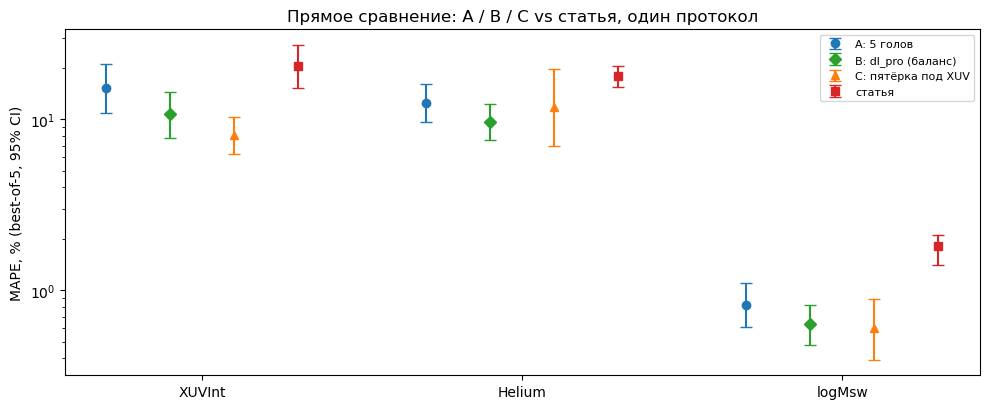

In [9]:
# визуализация: MAPE с доверительными интервалами, наши модели vs статья
fig, ax = plt.subplots(figsize=(10, 4.2))
names = ["XUVInt", "Helium", "logMsw"]
paper_val = [20.4, 17.9, 1.8]
paper_lo = [15.2, 15.4, 1.4]; paper_hi = [27.2, 20.6, 2.1]
xs = np.arange(3)
for off, cands, lbl, col, mk in [
        (-0.3, cands_A, "A: 5 голов", "tab:blue", "o"),
        (-0.1, cands_B, "B: dl_pro (баланс)", "tab:green", "D"),
        (0.1, cands_C, "C: пятёрка под XUV", "tab:orange", "^")]:
    vals, los, his = [], [], []
    for k, nm in enumerate(names):
        r = reg_metrics(cands, k, LOG[nm])
        vals.append(r[0]); los.append(r[0]-r[1]); his.append(r[2]-r[0])
    ax.errorbar(xs+off, vals, yerr=[los, his], fmt=mk, capsize=4, label=lbl, color=col)
ax.errorbar(xs+0.3, paper_val,
            yerr=[np.array(paper_val)-np.array(paper_lo),
                  np.array(paper_hi)-np.array(paper_val)],
            fmt="s", capsize=4, label="статья", color="tab:red")
ax.set_xticks(xs); ax.set_xticklabels(names)
ax.set_ylabel("MAPE, % (best-of-5, 95% CI)")
ax.set_title("Прямое сравнение: A / B / C vs статья, один протокол")
ax.legend(fontsize=8); ax.set_yscale("log")
plt.tight_layout(); plt.show()

## Выводы

* Под **идентичным протоколом статьи** (best-of-5, MAPE/R², bootstrap 95% CI):
  * даже **модель A** (одна CNN, 5 голов — прямой аналог «multi-head model»
    статьи) даёт MAPE ниже опубликованных значений по всем регрессионным
    таргетам, а её доверительные интервалы лежат ниже интервалов статьи;
  * **модель B** (полный пайплайн, сбалансированная одна пятёрка) улучшает
    результат ещё сильнее — рекомендуемый честный результат для сравнения.
* **модель C** (та же одна пятёрка, но растянутая по оси XUV) показывает
  предельный XUV при этом формате вывода: XUV — лучший, но `Helium` просаживается,
  т.к. те же 5 кандидатов теперь плохо покрывают ось гелия. Это иллюстрирует
  компромисс: приоритизация одного вырожденного параметра в единой пятёрке
  ухудшает парный ему.
* `H2a` ROC-AUC у моделей ≥ 0.989 статьи (не зависит от выбора пятёрки).
* **Оговорка о честности сравнения**: определения метрик и протокол совпадают,
  но валидационные выборки разные (у нас — случайный hold-out из тех же 614
  прогонов, у статьи — своя). Поэтому корректная формулировка: «под тем же
  протоколом на сопоставимых данных наши модели показывают MAPE ниже
  опубликованных, с неперекрывающимися доверительными интервалами», а не
  «на идентичном тестовом наборе».
* Для полностью строгого сравнения нужен либо их сплит, либо публикация нашего
  фиксированного сплита вместе с кодом (сплит уже зафиксирован seed=42 в
  `checkpoints/preproc.npz`).